# YOLO Segmentation Clean Baseline

Clean baseline before later improvements. This keeps the original loading, plotting, and healthy-negative evaluation style, while making minority oversampling optional and model selection configurable.


In [1]:
# !pip install roboflow

# from roboflow import Roboflow
# rf = Roboflow(api_key="KOEk0qLzBFDc7zfyxtgs")
# project = rf.workspace("lets-try-this").project("shrimpdishandsegv2")
# version = project.version(1)
# dataset = version.download("yolo26")
                

In [2]:
# /kaggle/working/shrimpDisHandSegV2-1

In [3]:
import importlib.util
import os
import subprocess
import sys

if importlib.util.find_spec('roboflow') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'roboflow'])

from roboflow import Roboflow

ROBOFLOW_API_KEY_DIRECT = 'KOEk0qLzBFDc7zfyxtgs'
ROBOFLOW_WORKSPACE = 'lets-try-this'
ROBOFLOW_PROJECT = 'shrimpdishandsegv2'
ROBOFLOW_VERSION = 1
ROBOFLOW_FORMAT = 'yolo26'


def get_roboflow_api_key():
    if ROBOFLOW_API_KEY_DIRECT.strip():
        return ROBOFLOW_API_KEY_DIRECT.strip()
    try:
        from kaggle_secrets import UserSecretsClient
        key = UserSecretsClient().get_secret('ROBOFLOW_API_KEY')
        if key:
            return key
    except Exception:
        pass
    return os.environ.get('ROBOFLOW_API_KEY', '').strip()


api_key = get_roboflow_api_key()
if not api_key:
    raise RuntimeError(
        'Missing Roboflow API key. Add a Kaggle Secret named ROBOFLOW_API_KEY, '
        'set the ROBOFLOW_API_KEY environment variable, or temporarily fill ROBOFLOW_API_KEY_DIRECT.'
    )

rf = Roboflow(api_key=api_key)
project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
version = project.version(ROBOFLOW_VERSION)
dataset = version.download(ROBOFLOW_FORMAT)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 98.9 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to shrimpDisHandSegV2-1 in yolo26:: 100%|██████████| 2301/2301 [00:00<00:00, 3119.82it/s]


In [4]:
import os
import random
import re
import shutil
from collections import defaultdict, Counter
from pathlib import Path

SEED = 42
random.seed(SEED)

base_path = '/kaggle/working/shrimpDisHandSegV2-1'
train_path = os.path.join(base_path, 'train')
IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

# Prevent leakage from multiple photos of the same shrimp.
# Expected original filename: <diseasename>-<shrimpid>-img-<imgnum>.jpg
# Roboflow may export names like <diseasename>-<shrimpid>-img-<imgnum>_jpg.rf.<hash>.jpg.
# Example disease names: Healthy, BG, WSSV_BG, WSSV.
GROUP_SPLIT_BY_SHRIMP = True
REBUILD_SPLIT_FROM_ALL_SPLITS = True
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10

SHRIMP_NAME_PATTERN = re.compile(
    r'^(?P<disease>Healthy|BG|WSSV_BG|WSSV)-(?P<shrimp_id>.+)-img-(?P<img_num>\d+)$',
    re.IGNORECASE,
)


def normalize_roboflow_stem(stem):
    """Recover the original filename stem from Roboflow-exported names."""
    # Roboflow commonly converts `name.jpg` to `name_jpg.rf.<hash>.jpg`.
    stem = re.sub(r'_(jpg|jpeg|png|bmp|webp)\.rf\.[0-9a-f]+$', '', stem, flags=re.IGNORECASE)
    # Handle a less common case where only `.rf.<hash>` is appended.
    stem = re.sub(r'\.rf\.[0-9a-f]+$', '', stem, flags=re.IGNORECASE)
    return stem

for split in ['train', 'valid', 'test']:
    for sub in ['images', 'labels']:
        os.makedirs(os.path.join(base_path, split, sub), exist_ok=True)


def parse_shrimp_group_key(image_name):
    """Return a stable group key so all images from one shrimp stay in one split."""
    stem = normalize_roboflow_stem(Path(image_name).stem)
    match = SHRIMP_NAME_PATTERN.match(stem)
    if not match:
        return f'unparsed::{Path(image_name).stem}', 'unparsed', None, None

    disease = match.group('disease')
    shrimp_id = match.group('shrimp_id')
    img_num = int(match.group('img_num'))

    # Include disease in the key to avoid accidental collisions if shrimp ids restart per disease folder/batch.
    # If shrimp_id is globally unique across all diseases, this is equivalent for leakage prevention.
    group_key = f'{disease.lower()}::{shrimp_id}'
    return group_key, disease, shrimp_id, img_num


def image_files_in_split(split):
    image_dir = Path(base_path) / split / 'images'
    return sorted(
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


def move_image_and_label(image_path, target_split):
    target_img_dir = Path(base_path) / target_split / 'images'
    target_lbl_dir = Path(base_path) / target_split / 'labels'
    target_img_dir.mkdir(parents=True, exist_ok=True)
    target_lbl_dir.mkdir(parents=True, exist_ok=True)

    label_name = f'{image_path.stem}.txt'
    label_src = image_path.parent.parent / 'labels' / label_name
    image_dst = target_img_dir / image_path.name
    label_dst = target_lbl_dir / label_name

    if image_path.resolve() != image_dst.resolve():
        if image_dst.exists():
            raise FileExistsError(f'Duplicate image destination would be overwritten: {image_dst}')
        shutil.move(str(image_path), str(image_dst))

    if label_src.exists():
        if label_src.resolve() != label_dst.resolve():
            if label_dst.exists():
                raise FileExistsError(f'Duplicate label destination would be overwritten: {label_dst}')
            shutil.move(str(label_src), str(label_dst))
    else:
        label_dst.write_text('')


def rebuild_train_pool_from_all_splits():
    all_images = []
    for split in ['train', 'valid', 'test']:
        all_images.extend(image_files_in_split(split))

    for image_path in sorted(all_images):
        move_image_and_label(image_path, 'train')

    return image_files_in_split('train')


def remove_yolo_label_caches(root):
    for cache_path in Path(root).glob('**/*.cache'):
        cache_path.unlink()
        print(f'Removed stale cache: {cache_path}')


def split_grouped_by_shrimp():
    if REBUILD_SPLIT_FROM_ALL_SPLITS:
        image_paths = rebuild_train_pool_from_all_splits()
    else:
        image_paths = image_files_in_split('train')

    groups = defaultdict(list)
    disease_counts = Counter()
    unparsed = []

    for image_path in image_paths:
        group_key, disease, shrimp_id, img_num = parse_shrimp_group_key(image_path.name)
        groups[group_key].append(image_path.name)
        disease_counts[disease] += 1
        if disease == 'unparsed':
            unparsed.append(image_path.name)

    group_items = sorted(groups.items(), key=lambda item: item[0])
    random.Random(SEED).shuffle(group_items)

    n_groups = len(group_items)
    train_group_count = int(TRAIN_RATIO * n_groups)
    val_group_count = int(VAL_RATIO * n_groups)

    train_groups = group_items[:train_group_count]
    val_groups = group_items[train_group_count:train_group_count + val_group_count]
    test_groups = group_items[train_group_count + val_group_count:]

    split_to_groups = {
        'train': train_groups,
        'valid': val_groups,
        'test': test_groups,
    }

    for split, split_groups in split_to_groups.items():
        for _, filenames in split_groups:
            for filename in filenames:
                move_image_and_label(Path(base_path) / 'train' / 'images' / filename, split)

    print('Shrimp-grouped split complete:')
    for split, split_groups in split_to_groups.items():
        image_count = sum(len(filenames) for _, filenames in split_groups)
        print(f'  - {split}: {len(split_groups)} shrimp groups, {image_count} images')

    print('Source filename disease counts before split:', dict(sorted(disease_counts.items())))
    if unparsed:
        print(f'Warning: {len(unparsed)} filenames did not match the shrimp naming pattern. They were split as single-image groups.')
        print('First unparsed examples:', unparsed[:10])

    # Hard leakage check: no shrimp group key should appear in more than one split.
    group_to_split = {}
    leakage = []
    for split in ['train', 'valid', 'test']:
        for image_path in image_files_in_split(split):
            group_key, *_ = parse_shrimp_group_key(image_path.name)
            previous_split = group_to_split.setdefault(group_key, split)
            if previous_split != split:
                leakage.append((group_key, previous_split, split, image_path.name))

    if leakage:
        raise RuntimeError(f'Shrimp-level split leakage detected: {leakage[:10]}')
    print('Shrimp-level leakage check passed.')
    remove_yolo_label_caches(base_path)


if GROUP_SPLIT_BY_SHRIMP:
    split_grouped_by_shrimp()
else:
    valid_images_dir = Path(base_path) / 'valid' / 'images'
    test_images_dir = Path(base_path) / 'test' / 'images'

    if not any(valid_images_dir.glob('*')) and not any(test_images_dir.glob('*')):
        image_files = sorted(
            f for f in os.listdir(os.path.join(train_path, 'images'))
            if f.lower().endswith(IMAGE_EXTENSIONS)
        )
        random.shuffle(image_files)

        train_count = int(0.8 * len(image_files))
        val_count = int(0.1 * len(image_files))

        val_files = image_files[train_count:train_count + val_count]
        test_files = image_files[train_count + val_count:]

        def move_files(files, target_split):
            for f in files:
                move_image_and_label(Path(train_path) / 'images' / f, target_split)

        move_files(val_files, 'valid')
        move_files(test_files, 'test')
        print(f"Image-level split complete: {len(image_files) - len(val_files) - len(test_files)} train, {len(val_files)} val, {len(test_files)} test")
        remove_yolo_label_caches(base_path)
    else:
        print('Existing valid/test split detected. Keeping downloaded split.')


Shrimp-grouped split complete:
  - train: 332 shrimp groups, 913 images
  - valid: 41 shrimp groups, 116 images
  - test: 43 shrimp groups, 120 images
Source filename disease counts before split: {'BG': 198, 'Healthy': 403, 'WSSV': 328, 'WSSV_BG': 220}
Shrimp-level leakage check passed.


In [11]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('ultralytics') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics'])

from ultralytics import YOLO
import os
from pathlib import Path

base_path = '/kaggle/working/shrimpDisHandSegV2-1'
data_yaml_path = os.path.join(base_path, 'data.yaml')

# Keep the model name and run name tied together so reports are not mislabeled.
# Comment in/out models here for the baseline run.
YOLO_MODELS = [
    # 'yolov8n-seg.pt',
    # 'yolov8m-seg.pt',
    'yolo11n-seg.pt',
    # 'yolo11m-seg.pt',
    # 'yolo26n-seg.pt',
    # 'yolo26m-seg.pt',
]

YOLO_MODEL = YOLO_MODELS[0]
MODEL_STEM = Path(YOLO_MODEL).stem
RUN_BASE_NAME = f'{MODEL_STEM}_shrimp_seg_clean_baseline'

# Load once here as a smoke check. Training cells instantiate fresh models per experiment.
model = YOLO(YOLO_MODEL)
print('Configured segmentation models:')
for configured_model in YOLO_MODELS:
    print(f'  - {configured_model}')
print(f'Run name prefix: {RUN_BASE_NAME}')

Configured segmentation models:
  - yolo11n-seg.pt
Run name prefix: yolo11n-seg_shrimp_seg_clean_baseline


In [12]:
import yaml

# Update data.yaml to use correct paths
with open(data_yaml_path, 'r') as f:
    content = yaml.safe_load(f)

content['train'] = '/kaggle/working/shrimpDisHandSegV2-1/train/images'
content['val'] = '/kaggle/working/shrimpDisHandSegV2-1/valid/images'
content['test'] = '/kaggle/working/shrimpDisHandSegV2-1/test/images'

with open(data_yaml_path, 'w') as f:
    yaml.dump(content, f)

print("data.yaml updated with absolute paths.")

data.yaml updated with absolute paths.


### Exploratory Data Analysis (EDA)
We will analyze the dataset to understand the class distribution and visualize some sample images with their masks.

In [13]:
import os
import yaml
import matplotlib.pyplot as plt
import cv2
import numpy as np
from collections import Counter
from pathlib import Path

# Load class names from data.yaml. Empty label files are healthy shrimp negatives.
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config.get('names', [])
HEALTHY_CLASS_NAME = 'healthy'
print(f"Disease mask classes found: {class_names}")
print(f"Empty label files will be treated as: {HEALTHY_CLASS_NAME} shrimp negatives")


def split_label_stats(label_dir):
    instance_counts = Counter()
    labeled_images = 0
    healthy_images = 0
    missing_or_empty = 0
    label_dir = Path(label_dir)
    for label_file in label_dir.glob('*.txt'):
        lines = [line.strip() for line in label_file.read_text().splitlines() if line.strip()]
        if not lines:
            healthy_images += 1
            continue
        labeled_images += 1
        for line in lines:
            class_id = int(float(line.split()[0]))
            instance_counts[class_id] += 1
    return {
        'instance_counts': instance_counts,
        'labeled_images': labeled_images,
        'healthy_images': healthy_images,
        'total_label_files': labeled_images + healthy_images,
    }


stats = {}
for split in ['train', 'valid', 'test']:
    label_dir = os.path.join(base_path, split, 'labels')
    stats[split] = split_label_stats(label_dir)

for split, split_stats in stats.items():
    print(f"\n{split.capitalize()} Split:")
    print(f"  - labeled disease images: {split_stats['labeled_images']}")
    print(f"  - healthy negative images: {split_stats['healthy_images']}")
    for cid, count in split_stats['instance_counts'].items():
        name = class_names[cid] if cid < len(class_names) else f"Unknown({cid})"
        print(f"  - {name}: {count} mask instances")

Disease mask classes found: ['BG', 'WSSV']
Empty label files will be treated as: healthy shrimp negatives

Train Split:
  - labeled disease images: 600
  - healthy negative images: 313
  - WSSV: 458 mask instances
  - BG: 353 mask instances

Valid Split:
  - labeled disease images: 67
  - healthy negative images: 49
  - BG: 44 mask instances
  - WSSV: 53 mask instances

Test Split:
  - labeled disease images: 79
  - healthy negative images: 41
  - BG: 65 mask instances
  - WSSV: 58 mask instances


### Visualizing Class Imbalance
An imbalanced dataset can cause the model to be biased. Let's visualize the distribution across our splits.

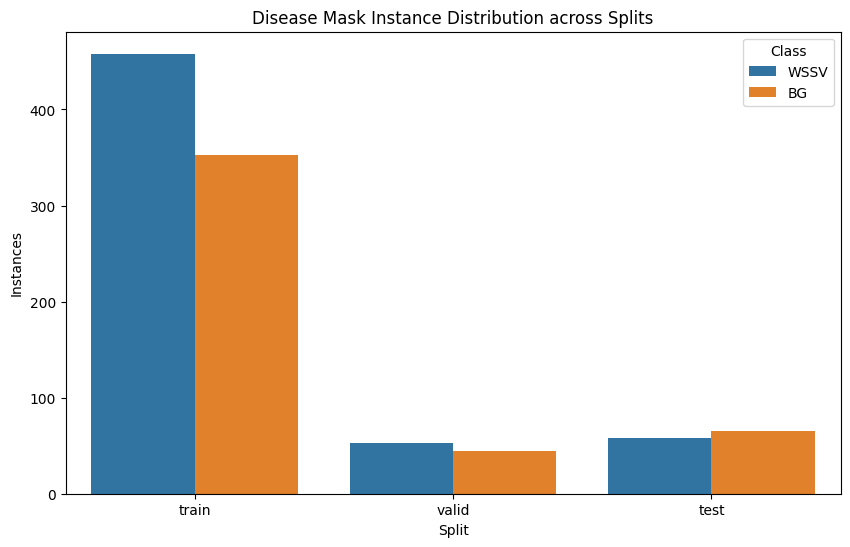

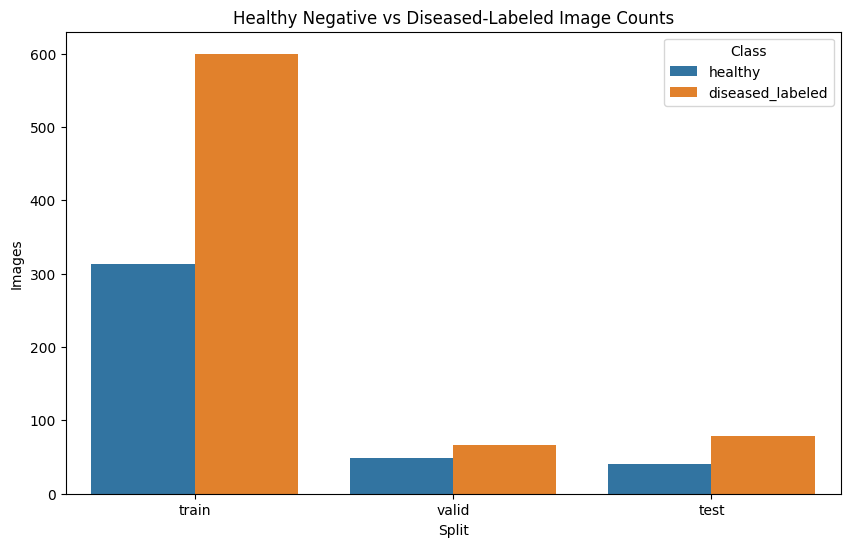

Train: 43.53% blackgill instances; 34.28% healthy negative images
Valid: 45.36% blackgill instances; 42.24% healthy negative images
Test: 52.85% blackgill instances; 34.17% healthy negative images


In [14]:
import pandas as pd
import seaborn as sns

instance_plot_data = []
image_plot_data = []
for split, split_stats in stats.items():
    image_plot_data.append({'Split': split, 'Class': HEALTHY_CLASS_NAME, 'Images': split_stats['healthy_images']})
    image_plot_data.append({'Split': split, 'Class': 'diseased_labeled', 'Images': split_stats['labeled_images']})
    for cid, count in split_stats['instance_counts'].items():
        instance_plot_data.append({'Split': split, 'Class': class_names[cid], 'Instances': count})

if instance_plot_data:
    df_instances = pd.DataFrame(instance_plot_data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_instances, x='Split', y='Instances', hue='Class')
    plt.title('Disease Mask Instance Distribution across Splits')
    plt.show()

if image_plot_data:
    df_images = pd.DataFrame(image_plot_data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_images, x='Split', y='Images', hue='Class')
    plt.title('Healthy Negative vs Diseased-Labeled Image Counts')
    plt.show()

for split, split_stats in stats.items():
    total_instances = sum(split_stats['instance_counts'].values())
    blackgill_ratio = (split_stats['instance_counts'].get(0, 0) / max(1, total_instances)) * 100
    healthy_ratio = (split_stats['healthy_images'] / max(1, split_stats['total_label_files'])) * 100
    print(f"{split.capitalize()}: {blackgill_ratio:.2f}% blackgill instances; {healthy_ratio:.2f}% healthy negative images")

#### Observations:
1. **High Disease-Class Imbalance**: `blackgill` is a small fraction of disease mask instances.
2. **Healthy Negatives Are Real Data**: Empty label files are healthy shrimp images, not missing annotations.
3. **Evaluation Must Split Responsibilities**:
   - Diseased/labeled images should be evaluated with box/mask mAP and recall.
   - Healthy/empty-label images should be evaluated with false-positive rate and false-positive masks per image.

**Recommendation**: Keep healthy images in training as negative controls, but report healthy false-positive metrics separately instead of mixing them into disease mask mAP interpretation.

### Optional Minority RandAugment Oversampling
The baseline starts with `ENABLE_MINORITY_OVERSAMPLING = False`. Turn it on later to create RandAugment-based minority samples. The implementation uses label-preserving photometric RandAugment operations so segmentation polygons remain valid.


In [15]:
import cv2
import os
import random
from pathlib import Path
from PIL import Image, ImageEnhance, ImageOps

IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

ENABLE_MINORITY_OVERSAMPLING = False
MINORITY_CLASS_ID = 0
MINORITY_OVERSAMPLING_MULTIPLIER = 8
RAND_AUGMENT_NUM_OPS = 2
RAND_AUGMENT_MAGNITUDE = 9
RAND_AUGMENT_MAX_MAGNITUDE = 30

# Geometric RandAugment ops are intentionally excluded here because this is
# segmentation data. Photometric ops preserve the existing polygon labels.
RAND_AUGMENT_OPS = [
    'autocontrast',
    'equalize',
    'solarize',
    'posterize',
    'color',
    'contrast',
    'brightness',
    'sharpness',
]


def find_image_for_label(image_dir, label_file):
    stem = Path(label_file).stem
    for ext in IMAGE_EXTENSIONS:
        candidate = Path(image_dir) / f'{stem}{ext}'
        if candidate.exists():
            return candidate
    return None


def remove_yolo_label_caches(base_path):
    for cache_path in Path(base_path).glob('**/*.cache'):
        cache_path.unlink()
        print(f'Removed stale cache: {cache_path}')


def count_labeled_images(label_dir):
    labeled = 0
    healthy = 0
    for label_path in Path(label_dir).glob('*.txt'):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        if lines:
            labeled += 1
        else:
            healthy += 1
    return labeled, healthy


def randaugment_level(max_value, signed=False):
    magnitude = RAND_AUGMENT_MAGNITUDE / RAND_AUGMENT_MAX_MAGNITUDE
    value = magnitude * max_value
    if signed and random.random() < 0.5:
        value *= -1
    return value


def apply_randaugment_op(image, op_name):
    if op_name == 'autocontrast':
        return ImageOps.autocontrast(image)
    if op_name == 'equalize':
        return ImageOps.equalize(image)
    if op_name == 'solarize':
        threshold = int(256 - randaugment_level(256))
        return ImageOps.solarize(image, threshold=max(0, min(256, threshold)))
    if op_name == 'posterize':
        bits = int(round(8 - randaugment_level(4)))
        return ImageOps.posterize(image, bits=max(4, min(8, bits)))
    if op_name == 'color':
        factor = 1.0 + randaugment_level(0.9, signed=True)
        return ImageEnhance.Color(image).enhance(max(0.1, factor))
    if op_name == 'contrast':
        factor = 1.0 + randaugment_level(0.9, signed=True)
        return ImageEnhance.Contrast(image).enhance(max(0.1, factor))
    if op_name == 'brightness':
        factor = 1.0 + randaugment_level(0.9, signed=True)
        return ImageEnhance.Brightness(image).enhance(max(0.1, factor))
    if op_name == 'sharpness':
        factor = 1.0 + randaugment_level(0.9, signed=True)
        return ImageEnhance.Sharpness(image).enhance(max(0.1, factor))
    raise ValueError(f'Unsupported RandAugment op: {op_name}')


def apply_label_preserving_randaugment(image):
    image = image.convert('RGB')
    ops = random.choices(RAND_AUGMENT_OPS, k=RAND_AUGMENT_NUM_OPS)
    for op_name in ops:
        image = apply_randaugment_op(image, op_name)
    return image


def augment_minority_class(base_path, class_id_to_target=0, multiplier=5):
    train_img_dir = os.path.join(base_path, 'train', 'images')
    train_lbl_dir = os.path.join(base_path, 'train', 'labels')

    label_files = [f for f in os.listdir(train_lbl_dir) if f.endswith('.txt')]
    augmented_count = 0
    skipped_count = 0
    random.seed(SEED)

    for label_file in label_files:
        if label_file.startswith('randaug_'):
            continue

        label_path = os.path.join(train_lbl_dir, label_file)
        with open(label_path, 'r') as f:
            content = [line.strip() for line in f.readlines() if line.strip()]

        has_target = any(int(line.split()[0]) == class_id_to_target for line in content)
        if not has_target:
            continue

        img_path = find_image_for_label(train_img_dir, label_file)
        if img_path is None:
            skipped_count += 1
            continue

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            skipped_count += 1
            continue

        for m in range(multiplier):
            aug_img = apply_label_preserving_randaugment(image)
            aug_image_name = f'randaug_{m}_{img_path.stem}.jpg'
            aug_label_name = f'randaug_{m}_{Path(label_file).stem}.txt'
            aug_img.save(os.path.join(train_img_dir, aug_image_name), quality=95)
            with open(os.path.join(train_lbl_dir, aug_label_name), 'w') as f:
                f.write('\n'.join(content) + '\n')
            augmented_count += 1

    remove_yolo_label_caches(base_path)
    labeled, healthy = count_labeled_images(train_lbl_dir)
    target_name = class_names[class_id_to_target] if class_id_to_target < len(class_names) else str(class_id_to_target)
    print(f'Created {augmented_count} RandAugment samples for class {target_name}.')
    print(f'Skipped {skipped_count} source labels due to missing image or invalid labels.')
    print(f'Train labels after augmentation: {labeled} diseased/labeled images, {healthy} healthy negative label files.')


if ENABLE_MINORITY_OVERSAMPLING:
    augment_minority_class(base_path, class_id_to_target=MINORITY_CLASS_ID, multiplier=MINORITY_OVERSAMPLING_MULTIPLIER)
else:
    print('Minority RandAugment oversampling disabled for the clean baseline.')


Minority RandAugment oversampling disabled for the clean baseline.


### Clean Baseline Training and Healthy-Negative Evaluation
Train the configured YOLO segmentation model list with clean/light augmentation and rank by healthy-aware score.


In [ ]:
import csv
import gc
import math
import shutil
import time
from pathlib import Path

import cv2
import pandas as pd
import yaml
from IPython.display import display

EXPERIMENT_ROOT = Path('/kaggle/working/shrimp_yolo_seg_clean_baseline')
RUNS_DIR = Path('/kaggle/working/runs/segment')
REPORT_DIR = EXPERIMENT_ROOT / 'reports'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

COUNT_PENALTY_WEIGHT = 0.05
DISEASE_MISS_PENALTY_WEIGHT = 0.15
HEALTHY_FP_PENALTY_WEIGHT = 0.10
PREDICT_CONF_FOR_COUNT = 0.25

EXPERIMENTS = [
    {
        'key': 'clean_baseline',
        'name': 'Clean Baseline - Natural Split',
        'apply_clahe': False,
    },
]

CLEAN_TRAIN_ARGS = {
    # Cleaner than the earlier run: avoid stacked RandAugment + erasing + mosaic noise.
    'auto_augment': None,
    'erasing': 0.0,
    'mosaic': 0.0,
    'mixup': 0.0,
    'cutmix': 0.0,
    'copy_paste': 0.0,
    'fliplr': 0.5,
    'flipud': 0.0,
    'hsv_h': 0.01,
    'hsv_s': 0.35,
    'hsv_v': 0.20,
    'degrees': 0.0,
    'translate': 0.05,
    'scale': 0.20,
    'shear': 0.0,
    'perspective': 0.0,
}


def remove_yolo_label_caches(root):
    for cache_path in Path(root).glob('**/*.cache'):
        cache_path.unlink()
        print(f'Removed stale cache: {cache_path}')


def apply_clahe_to_dataset(image_dir):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image_files = []
    for ext in IMAGE_EXTENSIONS:
        image_files.extend(Path(image_dir).glob(f'*{ext}'))

    print(f'Applying CLAHE to {len(image_files)} images in {image_dir}...')
    for img_path in image_files:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        l2 = clahe.apply(l)
        enhanced = cv2.cvtColor(cv2.merge((l2, a, b)), cv2.COLOR_LAB2BGR)
        cv2.imwrite(str(img_path), enhanced)


def count_labeled_images(label_dir):
    labeled = 0
    healthy = 0
    instances = 0
    for label_path in Path(label_dir).glob('*.txt'):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        if lines:
            labeled += 1
            instances += len(lines)
        else:
            healthy += 1
    return {'labeled_images': labeled, 'healthy_images': healthy, 'instances': instances}


def write_data_yaml(dataset_dir, yaml_path, val_dir='valid', test_dir='test'):
    with open(data_yaml_path, 'r') as f:
        content = yaml.safe_load(f)
    content['train'] = str(Path(dataset_dir) / 'train' / 'images')
    content['val'] = str(Path(dataset_dir) / val_dir / 'images')
    content['test'] = str(Path(dataset_dir) / test_dir / 'images')
    with open(yaml_path, 'w') as f:
        yaml.safe_dump(content, f, sort_keys=False)
    return yaml_path


def copy_dataset_for_experiment(exp_key):
    src = Path(base_path)
    dst = EXPERIMENT_ROOT / exp_key / 'dataset'
    if dst.exists():
        shutil.rmtree(dst)
    ignore = shutil.ignore_patterns('runs', '*.cache', '.clahe_applied')
    shutil.copytree(src, dst, ignore=ignore)
    remove_yolo_label_caches(dst)
    return dst



def copy_split_by_label_state(src_dataset, dst_dataset, split, want_labeled):
    src_images = Path(src_dataset) / split / 'images'
    src_labels = Path(src_dataset) / split / 'labels'
    dst_images = Path(dst_dataset) / split / 'images'
    dst_labels = Path(dst_dataset) / split / 'labels'
    dst_images.mkdir(parents=True, exist_ok=True)
    dst_labels.mkdir(parents=True, exist_ok=True)

    copied = 0
    for label_path in sorted(src_labels.glob('*.txt')):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        is_labeled = bool(lines)
        if is_labeled != want_labeled:
            continue
        image_path = find_image_for_label(src_images, label_path.name)
        if image_path is None:
            continue
        shutil.copy2(image_path, dst_images / image_path.name)
        shutil.copy2(label_path, dst_labels / label_path.name)
        copied += 1
    return copied


def make_state_eval_dataset(src_dataset, exp_key, state_name, want_labeled):
    dst = EXPERIMENT_ROOT / exp_key / f'dataset_{state_name}_eval'
    if dst.exists():
        shutil.rmtree(dst)

    # Train path is unused for evaluation, but YOLO expects it in data.yaml.
    for sub in ['images', 'labels']:
        (dst / 'train' / sub).mkdir(parents=True, exist_ok=True)
    copied = {}
    for split in ['valid', 'test']:
        copied[split] = copy_split_by_label_state(src_dataset, dst, split, want_labeled=want_labeled)
    yaml_path = dst / f'data_{state_name}.yaml'
    write_data_yaml(dst, yaml_path)
    print(f'{state_name} eval dataset for {exp_key}: {copied}')
    return dst, yaml_path, copied


def make_labeled_only_eval_dataset(src_dataset, exp_key):
    return make_state_eval_dataset(src_dataset, exp_key, 'labeled_only', want_labeled=True)


def make_healthy_only_eval_dataset(src_dataset, exp_key):
    return make_state_eval_dataset(src_dataset, exp_key, 'healthy_only', want_labeled=False)


def metric_value(metrics, dotted_path, default=float('nan')):
    obj = metrics
    for part in dotted_path.split('.'):
        if not hasattr(obj, part):
            return default
        obj = getattr(obj, part)
    try:
        return float(obj)
    except Exception:
        return default


def count_prediction_errors(model, images_dir, labels_dir, conf=PREDICT_CONF_FOR_COUNT):
    image_paths = []
    for ext in IMAGE_EXTENSIONS:
        image_paths.extend(Path(images_dir).glob(f'*{ext}'))
    image_paths = sorted(image_paths)
    if not image_paths:
        return {
            'images': 0,
            'gt_total': 0,
            'pred_box_total': 0,
            'pred_mask_total': 0,
            'box_count_mae': float('nan'),
            'mask_count_mae': float('nan'),
            'box_count_exact': float('nan'),
            'mask_count_exact': float('nan'),
            'disease_images': 0,
            'disease_box_miss_images': 0,
            'disease_mask_miss_images': 0,
            'disease_box_miss_rate': float('nan'),
            'disease_mask_miss_rate': float('nan'),
        }

    results = model.predict(source=[str(p) for p in image_paths], imgsz=640, conf=conf, verbose=False)
    box_errors = []
    mask_errors = []
    box_exact = []
    mask_exact = []
    gt_total = 0
    pred_box_total = 0
    pred_mask_total = 0
    disease_images = 0
    disease_box_miss_images = 0
    disease_mask_miss_images = 0

    for image_path, result in zip(image_paths, results):
        label_path = Path(labels_dir) / f'{image_path.stem}.txt'
        gt_count = 0
        if label_path.exists():
            gt_count = len([line for line in label_path.read_text().splitlines() if line.strip()])
        box_count = len(result.boxes) if result.boxes is not None else 0
        mask_count = len(result.masks) if result.masks is not None else 0
        denom = max(1, gt_count)
        box_errors.append(abs(box_count - gt_count) / denom)
        mask_errors.append(abs(mask_count - gt_count) / denom)
        box_exact.append(float(box_count == gt_count))
        mask_exact.append(float(mask_count == gt_count))
        if gt_count > 0:
            disease_images += 1
            disease_box_miss_images += int(box_count == 0)
            disease_mask_miss_images += int(mask_count == 0)
        gt_total += gt_count
        pred_box_total += box_count
        pred_mask_total += mask_count

    disease_box_miss_rate = disease_box_miss_images / disease_images if disease_images else float('nan')
    disease_mask_miss_rate = disease_mask_miss_images / disease_images if disease_images else float('nan')

    return {
        'images': len(image_paths),
        'gt_total': gt_total,
        'pred_box_total': pred_box_total,
        'pred_mask_total': pred_mask_total,
        'box_count_mae': sum(box_errors) / len(box_errors),
        'mask_count_mae': sum(mask_errors) / len(mask_errors),
        'box_count_exact': sum(box_exact) / len(box_exact),
        'mask_count_exact': sum(mask_exact) / len(mask_exact),
        'disease_images': disease_images,
        'disease_box_miss_images': disease_box_miss_images,
        'disease_mask_miss_images': disease_mask_miss_images,
        'disease_box_miss_rate': disease_box_miss_rate,
        'disease_mask_miss_rate': disease_mask_miss_rate,
    }



def healthy_false_positive_summary(model, images_dir, conf=PREDICT_CONF_FOR_COUNT):
    image_paths = []
    for ext in IMAGE_EXTENSIONS:
        image_paths.extend(Path(images_dir).glob(f'*{ext}'))
    image_paths = sorted(image_paths)
    if not image_paths:
        return {
            'healthy_images': 0,
            'healthy_images_with_box_fp': 0,
            'healthy_images_with_mask_fp': 0,
            'healthy_box_fp_rate': float('nan'),
            'healthy_mask_fp_rate': float('nan'),
            'healthy_fp_boxes_total': 0,
            'healthy_fp_masks_total': 0,
            'healthy_fp_boxes_per_image': float('nan'),
            'healthy_fp_masks_per_image': float('nan'),
            'healthy_avg_fp_confidence': float('nan'),
        }

    results = model.predict(source=[str(p) for p in image_paths], imgsz=640, conf=conf, verbose=False)
    images_with_box_fp = 0
    images_with_mask_fp = 0
    box_total = 0
    mask_total = 0
    confidences = []

    for result in results:
        box_count = len(result.boxes) if result.boxes is not None else 0
        mask_count = len(result.masks) if result.masks is not None else 0
        if box_count > 0:
            images_with_box_fp += 1
            try:
                confidences.extend([float(v) for v in result.boxes.conf.detach().cpu().tolist()])
            except Exception:
                pass
        if mask_count > 0:
            images_with_mask_fp += 1
        box_total += box_count
        mask_total += mask_count

    n = len(image_paths)
    return {
        'healthy_images': n,
        'healthy_images_with_box_fp': images_with_box_fp,
        'healthy_images_with_mask_fp': images_with_mask_fp,
        'healthy_box_fp_rate': images_with_box_fp / n,
        'healthy_mask_fp_rate': images_with_mask_fp / n,
        'healthy_fp_boxes_total': box_total,
        'healthy_fp_masks_total': mask_total,
        'healthy_fp_boxes_per_image': box_total / n,
        'healthy_fp_masks_per_image': mask_total / n,
        'healthy_avg_fp_confidence': sum(confidences) / len(confidences) if confidences else 0.0,
    }


def read_best_epoch_from_results(run_path):
    results_csv = Path(run_path) / 'results.csv'
    if not results_csv.exists():
        return {}
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    mask_col = 'metrics/mAP50(M)'
    if mask_col not in df.columns:
        return {'epochs_ran': len(df)}
    best_idx = df[mask_col].idxmax()
    first = df.iloc[0]
    best = df.iloc[best_idx]
    last = df.iloc[-1]
    return {
        'epochs_ran': int(len(df)),
        'best_epoch_by_mask_map50': int(best['epoch']) if 'epoch' in df.columns else int(best_idx + 1),
        'first_train_seg_loss': float(first.get('train/seg_loss', float('nan'))),
        'best_val_mask_map50': float(best.get(mask_col, float('nan'))),
        'best_val_mask_map50_95': float(best.get('metrics/mAP50-95(M)', float('nan'))),
        'last_val_mask_map50': float(last.get(mask_col, float('nan'))),
        'last_val_mask_map50_95': float(last.get('metrics/mAP50-95(M)', float('nan'))),
        'last_train_seg_loss': float(last.get('train/seg_loss', float('nan'))),
        'last_val_seg_loss': float(last.get('val/seg_loss', float('nan'))),
        'seg_loss_gap_val_minus_train': float(last.get('val/seg_loss', float('nan')) - last.get('train/seg_loss', float('nan'))),
    }


def run_experiment(exp):
    print('\n' + '#' * 90)
    print(f"Starting experiment: {exp['name']}")
    print('#' * 90)

    dataset_dir = copy_dataset_for_experiment(exp['key'])
    if exp['apply_clahe']:
        for split in ['train', 'valid', 'test']:
            apply_clahe_to_dataset(dataset_dir / split / 'images')

    remove_yolo_label_caches(dataset_dir)
    yaml_path = dataset_dir / 'data.yaml'
    write_data_yaml(dataset_dir, yaml_path)
    labeled_eval_dir, labeled_eval_yaml, labeled_eval_counts = make_labeled_only_eval_dataset(dataset_dir, exp['key'])
    healthy_eval_dir, healthy_eval_yaml, healthy_eval_counts = make_healthy_only_eval_dataset(dataset_dir, exp['key'])

    split_counts = {}
    for split in ['train', 'valid', 'test']:
        split_counts[split] = count_labeled_images(dataset_dir / split / 'labels')
        print(f'{exp["key"]} {split}: {split_counts[split]}')

    run_name = f'{RUN_BASE_NAME}_{exp["key"]}'
    yolo = YOLO(YOLO_MODEL)
    start = time.time()
    yolo.train(
        data=str(yaml_path),
        task='segment',
        imgsz=640,
        epochs=100,
        batch=16,
        patience=30,
        seed=42,
        project=str(RUNS_DIR),
        name=run_name,
        exist_ok=True,
        pretrained=True,
        plots=True,
        verbose=True,
        **CLEAN_TRAIN_ARGS,
    )
    train_time_min = (time.time() - start) / 60

    run_path = RUNS_DIR / run_name
    best_path = run_path / 'weights' / 'best.pt'
    best_model = YOLO(str(best_path))

    full_val = best_model.val(data=str(yaml_path), split='val', imgsz=640, plots=True, verbose=False)
    full_test = best_model.val(data=str(yaml_path), split='test', imgsz=640, plots=True, verbose=False)
    labeled_val = best_model.val(data=str(labeled_eval_yaml), split='val', imgsz=640, plots=False, verbose=False)
    labeled_test = best_model.val(data=str(labeled_eval_yaml), split='test', imgsz=640, plots=False, verbose=False)

    test_count = count_prediction_errors(
        best_model,
        dataset_dir / 'test' / 'images',
        dataset_dir / 'test' / 'labels',
    )
    labeled_test_count = count_prediction_errors(
        best_model,
        labeled_eval_dir / 'test' / 'images',
        labeled_eval_dir / 'test' / 'labels',
    )
    healthy_test_fp = healthy_false_positive_summary(
        best_model,
        healthy_eval_dir / 'test' / 'images',
    )

    labeled_mask_map50 = metric_value(labeled_test, 'seg.map50')
    count_penalty = COUNT_PENALTY_WEIGHT * labeled_test_count['mask_count_mae']
    disease_miss_penalty = DISEASE_MISS_PENALTY_WEIGHT * labeled_test_count['disease_box_miss_rate']
    healthy_fp_penalty = HEALTHY_FP_PENALTY_WEIGHT * healthy_test_fp['healthy_mask_fp_rate']
    healthy_aware_score = labeled_mask_map50 - count_penalty - disease_miss_penalty - healthy_fp_penalty

    row = {
        'experiment': exp['key'],
        'name': exp['name'],
        'model': YOLO_MODEL,
        'run_name': run_name,
        'run_path': str(run_path),
        'best_pt': str(best_path),
        'apply_clahe': exp['apply_clahe'],
        'train_time_min': round(train_time_min, 2),
        'full_val_box_map50': metric_value(full_val, 'box.map50'),
        'full_val_mask_map50': metric_value(full_val, 'seg.map50'),
        'full_test_box_map50': metric_value(full_test, 'box.map50'),
        'full_test_mask_map50': metric_value(full_test, 'seg.map50'),
        'labeled_val_box_map50': metric_value(labeled_val, 'box.map50'),
        'labeled_val_mask_map50': metric_value(labeled_val, 'seg.map50'),
        'labeled_test_box_map50': metric_value(labeled_test, 'box.map50'),
        'labeled_test_mask_map50': labeled_mask_map50,
        'labeled_test_mask_map50_95': metric_value(labeled_test, 'seg.map'),
        'test_gt_instances': test_count['gt_total'],
        'test_pred_boxes': test_count['pred_box_total'],
        'test_pred_masks': test_count['pred_mask_total'],
        'test_mask_count_mae': test_count['mask_count_mae'],
        'labeled_test_gt_instances': labeled_test_count['gt_total'],
        'labeled_test_pred_boxes': labeled_test_count['pred_box_total'],
        'labeled_test_pred_masks': labeled_test_count['pred_mask_total'],
        'labeled_test_mask_count_mae': labeled_test_count['mask_count_mae'],
        'labeled_test_mask_count_exact': labeled_test_count['mask_count_exact'],
        'labeled_test_disease_box_miss_rate': labeled_test_count['disease_box_miss_rate'],
        'labeled_test_disease_mask_miss_rate': labeled_test_count['disease_mask_miss_rate'],
        'labeled_test_disease_box_miss_images': labeled_test_count['disease_box_miss_images'],
        'labeled_test_disease_mask_miss_images': labeled_test_count['disease_mask_miss_images'],
        'count_penalty': count_penalty,
        'disease_miss_penalty': disease_miss_penalty,
        'healthy_fp_penalty': healthy_fp_penalty,
        'healthy_test_images': healthy_test_fp['healthy_images'],
        'healthy_test_mask_fp_rate': healthy_test_fp['healthy_mask_fp_rate'],
        'healthy_test_box_fp_rate': healthy_test_fp['healthy_box_fp_rate'],
        'healthy_test_fp_masks_total': healthy_test_fp['healthy_fp_masks_total'],
        'healthy_test_fp_masks_per_image': healthy_test_fp['healthy_fp_masks_per_image'],
        'healthy_test_avg_fp_confidence': healthy_test_fp['healthy_avg_fp_confidence'],
        'healthy_aware_labeled_test_mask_map50': healthy_aware_score,
    }
    row.update(read_best_epoch_from_results(run_path))

    del yolo, best_model
    gc.collect()
    return row


experiment_results = []
for model_name in YOLO_MODELS:
    YOLO_MODEL = model_name
    MODEL_STEM = Path(YOLO_MODEL).stem
    RUN_BASE_NAME = f'{MODEL_STEM}_shrimp_seg_clean_baseline'
    for experiment in EXPERIMENTS:
        result = run_experiment(experiment)
        experiment_results.append(result)
        partial_df = pd.DataFrame(experiment_results)
        display(partial_df)
        partial_df.to_csv(REPORT_DIR / 'seg_clean_baseline_partial.csv', index=False)

results_df = pd.DataFrame(experiment_results)
results_df = results_df.sort_values('healthy_aware_labeled_test_mask_map50', ascending=False).reset_index(drop=True)
summary_csv = REPORT_DIR / 'seg_clean_baseline_summary.csv'
results_df.to_csv(summary_csv, index=False)
print(f'Saved summary: {summary_csv}')
display(results_df)

BEST_RUN = results_df.iloc[0].to_dict()
run_path = BEST_RUN['run_path']
best_model_path = BEST_RUN['best_pt']
print(f"Selected best run by healthy-aware labeled-test score: {BEST_RUN['run_name']}")
print(f'Best checkpoint: {best_model_path}')


##########################################################################################
Starting experiment: Clean Baseline - Natural Split
##########################################################################################
labeled_only eval dataset for clean_baseline: {'valid': 67, 'test': 79}
healthy_only eval dataset for clean_baseline: {'valid': 49, 'test': 41}
clean_baseline train: {'labeled_images': 600, 'healthy_images': 313, 'instances': 811}
clean_baseline valid: {'labeled_images': 67, 'healthy_images': 49, 'instances': 97}
clean_baseline test: {'labeled_images': 79, 'healthy_images': 41, 'instances': 123}
Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0,

### Inspect Metrics, Overfitting, Counts, and Visual Samples
Use the summary table to compare the clean no-CLAHE baseline against the CLAHE ablation. The labeled-only metrics remove healthy/empty-label validation/test images from evaluation, while the count-penalized score subtracts a penalty when predicted mask counts do not match ground-truth object counts.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
from pathlib import Path
from IPython.display import display

if 'results_df' not in globals():
    results_df = pd.read_csv(REPORT_DIR / 'seg_clean_baseline_summary.csv')
    BEST_RUN = results_df.iloc[0].to_dict()
    run_path = BEST_RUN['run_path']
    best_model_path = BEST_RUN['best_pt']

print('Baseline summary:')
display(results_df)

inspect_cols = [
    'experiment',
    'epochs_ran',
    'best_epoch_by_mask_map50',
    'best_val_mask_map50',
    'last_val_mask_map50',
    'last_train_seg_loss',
    'last_val_seg_loss',
    'seg_loss_gap_val_minus_train',
    'labeled_test_mask_map50',
    'labeled_test_mask_count_mae',
    'labeled_test_disease_box_miss_rate',
    'labeled_test_disease_mask_miss_rate',
    'disease_miss_penalty',
    'healthy_test_mask_fp_rate',
    'healthy_test_fp_masks_per_image',
    'healthy_aware_labeled_test_mask_map50',
]
print('Overfit/count inspection columns:')
display(results_df[[c for c in inspect_cols if c in results_df.columns]])

for _, row in results_df.iterrows():
    current_run_path = Path(row['run_path'])
    results_png = current_run_path / 'results.png'
    print(f"\nMetrics plot for {row['run_name']}: {results_png}")
    if results_png.exists():
        plt.figure(figsize=(12, 12))
        plt.imshow(mpimg.imread(results_png))
        plt.axis('off')
        plt.title(row['run_name'])
        plt.show()

print(f'Inspecting selected best run in: {run_path}')
val_batch = Path(run_path) / 'val_batch0_labels.jpg'
val_pred = Path(run_path) / 'val_batch0_pred.jpg'
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
if val_batch.exists():
    ax[0].imshow(mpimg.imread(val_batch))
    ax[0].set_title('Validation Ground Truth Labels')
else:
    ax[0].set_title('Validation Labels not found')
if val_pred.exists():
    ax[1].imshow(mpimg.imread(val_pred))
    ax[1].set_title('Validation Predictions')
else:
    ax[1].set_title('Validation Predictions not found')
for a in ax:
    a.axis('off')
plt.show()

### Test Set Evaluation, Healthy False Positives, and Visual Inspection
This block evaluates the selected best checkpoint on:
- the full test set,
- the diseased/labeled-only test subset,
- the healthy/empty-label test subset for false positives.

It then visualizes augmented training masks, diseased test predictions, and healthy test predictions so you can inspect both missed disease masks and false alarms on healthy shrimp.

In [ ]:
from ultralytics import YOLO
import glob
import matplotlib.pyplot as plt
import os
import random
from pathlib import Path

model_inference = YOLO(best_model_path)
selected_exp = BEST_RUN['experiment']
selected_dataset_dir = EXPERIMENT_ROOT / selected_exp / 'dataset'
selected_yaml = selected_dataset_dir / 'data.yaml'
selected_labeled_yaml = EXPERIMENT_ROOT / selected_exp / 'dataset_labeled_only_eval' / 'data_labeled_only.yaml'
selected_healthy_dir = EXPERIMENT_ROOT / selected_exp / 'dataset_healthy_only_eval'
selected_healthy_yaml = selected_healthy_dir / 'data_healthy_only.yaml'

print('Full test-set evaluation:')
full_test_metrics = model_inference.val(data=str(selected_yaml), split='test', imgsz=640, plots=True, verbose=False)
print('Labeled-only diseased test-set evaluation:')
labeled_test_metrics = model_inference.val(data=str(selected_labeled_yaml), split='test', imgsz=640, plots=False, verbose=False)
healthy_test_fp = healthy_false_positive_summary(model_inference, selected_healthy_dir / 'test' / 'images')

print('Full test mask mAP50:', metric_value(full_test_metrics, 'seg.map50'))
print('Labeled-only diseased test mask mAP50:', metric_value(labeled_test_metrics, 'seg.map50'))
print('Healthy test mask false-positive rate:', healthy_test_fp['healthy_mask_fp_rate'])
print('Healthy test false-positive masks per image:', healthy_test_fp['healthy_fp_masks_per_image'])


def draw_yolo_segmentation_labels(image_path, label_path):
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width = image.shape[:2]
    overlay = image.copy()
    colors = [(255, 70, 70), (70, 180, 255), (90, 220, 120), (240, 180, 60)]

    if label_path.exists():
        for line in label_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) < 7:
                continue
            cls_id = int(float(parts[0]))
            coords = np.array([float(v) for v in parts[1:]], dtype=np.float32).reshape(-1, 2)
            coords[:, 0] *= width
            coords[:, 1] *= height
            pts = coords.astype(np.int32)
            color = colors[cls_id % len(colors)]
            cv2.polylines(overlay, [pts], isClosed=True, color=color, thickness=2)
            cv2.fillPoly(overlay, [pts], color=color)
            x, y = pts[0]
            label = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
            cv2.putText(overlay, label, (int(x), int(y)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    return cv2.addWeighted(overlay, 0.35, image, 0.65, 0)


# Visualize augmented training ground-truth masks directly.
aug_images = sorted((selected_dataset_dir / 'train' / 'images').glob('aug_*'))
random.seed(42)
aug_images = random.sample(aug_images, k=min(6, len(aug_images)))

if aug_images:
    fig, axes = plt.subplots(len(aug_images), 1, figsize=(10, 5 * len(aug_images)))
    if len(aug_images) == 1:
        axes = [axes]
    for ax, image_path in zip(axes, aug_images):
        label_path = selected_dataset_dir / 'train' / 'labels' / f'{image_path.stem}.txt'
        ax.imshow(draw_yolo_segmentation_labels(image_path, label_path))
        ax.set_title(f'Augmented train GT mask: {image_path.name} | label exists={label_path.exists()}')
        ax.axis('off')
    plt.show()
else:
    print('No augmented training images found to visualize.')

# Visualize labeled test predictions.
test_images = []
for ext in IMAGE_EXTENSIONS:
    test_images.extend((selected_dataset_dir / 'test' / 'images').glob(f'*{ext}'))

def has_nonempty_label(image_path):
    label_path = selected_dataset_dir / 'test' / 'labels' / f'{image_path.stem}.txt'
    return label_path.exists() and bool(label_path.read_text().strip())

test_images = [p for p in sorted(test_images) if has_nonempty_label(p)]
test_images = test_images[:8]

results = model_inference.predict(source=[str(p) for p in test_images], conf=0.1, save=True, verbose=False)
for image_path, result in zip(test_images, results):
    plt.figure(figsize=(8, 8))
    plt.imshow(result.plot())
    plt.title(f'Labeled test prediction: {image_path.name} (conf > 0.1)')
    plt.axis('off')
    plt.show()

# Visualize healthy negative predictions to inspect false positives.
healthy_images = []
for ext in IMAGE_EXTENSIONS:
    healthy_images.extend((selected_healthy_dir / 'test' / 'images').glob(f'*{ext}'))
healthy_images = sorted(healthy_images)[:8]

if healthy_images:
    healthy_results = model_inference.predict(source=[str(p) for p in healthy_images], conf=0.1, save=False, verbose=False)
    for image_path, result in zip(healthy_images, healthy_results):
        plt.figure(figsize=(8, 8))
        plt.imshow(result.plot())
        box_count = len(result.boxes) if result.boxes is not None else 0
        mask_count = len(result.masks) if result.masks is not None else 0
        plt.title(f'Healthy test prediction: {image_path.name} | boxes={box_count}, masks={mask_count}')
        plt.axis('off')
        plt.show()
else:
    print('No healthy test images found to visualize.')


In [ ]:
print(f'Selected run path: {run_path}')
print(f'Selected checkpoint: {best_model_path}')
print(f'Report directory: {REPORT_DIR}')
print('Healthy-aware score = labeled_test_mask_map50 - COUNT_PENALTY_WEIGHT * labeled_test_mask_count_mae - DISEASE_MISS_PENALTY_WEIGHT * labeled_test_disease_box_miss_rate - HEALTHY_FP_PENALTY_WEIGHT * healthy_test_mask_fp_rate')